# AAV1 / sucrose PIC analysis

Working notebook for the preferential-interaction-coefficient (PIC, Γ₂₃) analysis
of the 10 ns AAV1 capsid trajectories in `pic_suc_7_9/10ns-simulations`.

Each section below is a self-contained plot built from the shared `CONDITIONS`
table loaded in Section 0 — edit the parameters at the top of any section
(which pair, which radius, normalized or not) and re-run just that cell.

**Reminders baked into this analysis, so they don't get lost on re-use:**
- Γ₂₃ is an *excess molecule count* — it scales with bulk sucrose concentration.
  Compare raw Γ₂₃ only at matched sucrose%, or divide by `mole_ratio` (n₃/n₁)
  first. See Section 4 for why that division isn't always a free lunch.
- The pipeline's own SEMs treat all ~1000 frames as independent samples; they
  aren't (sucrose crosses the 15 Å shell in ~720 ps). `CORR` below inflates
  every SEM to account for that — see Section 0.

## 0 · Setup, data loading, shared helpers

In [3]:
import os, re, csv, pickle
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.size": 12, "font.family": "Georgia",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#1b2624", "text.color": "#1b2624",
    "axes.labelcolor": "#1b2624", "xtick.color": "#1b2624", "ytick.color": "#1b2624",
})

# Colors are semantic and reused throughout -- keep them consistent if you
# add new plots. TEAL/PLUM mean pH 6/pH 8 in most charts below EXCEPT the
# region charts, where they mean 3-fold/5-fold -- each plotting function
# says which in its docstring.
TEAL, PLUM, AMBER, GREY = "#1f6f5c", "#7a3b66", "#a15c00", "#8a948e"
INK, GRID = "#1b2624", "#d8dcda"

### Where the data lives, and the frame-correlation correction

`ROOT` assumes this notebook sits inside `10ns-simulations/`, next to the
condition folders. Change it if you move the notebook.

`CORR` inflates the pipeline's reported SEMs. The pipeline treats all ~1000
saved frames as independent (see `RunningStats` in
`pic_calculation_exterior.py` — plain sum/sumsq/count, no autocorrelation
term). Sucrose actually crosses the 15 Å local domain in roughly
`15² / (6·D) ≈ 720 ps` (D ≈ 5.2e-6 cm²/s for sucrose in water), so a 10 ns run
holds about 10000/720 ≈ 14 independent shell-exchange events, not ~1000
frames. That inflates every true SEM by `sqrt(1001/14) ≈ 8.5×`. This is a
diffusion estimate, not a measured autocorrelation time -- the exact factor
is soft, but the order of magnitude is what turns naively-"significant"
gaps into noise, so it's applied everywhere below. Set `CORR = 1` to see the
pipeline's raw, over-optimistic error bars instead.

In [4]:
ROOT = Path(".")  # this notebook's own directory
CORR = 8.5

# Formulations from the ranking study; (pH, NaCl mM, sucrose %) -> (label, rank)
FORMULATIONS = {
    (6.0, 110, 8):  ("C", 1),
    (7.3, 170, 5):  ("F", 2),
    (6.0, 30, 12):  ("D", 3),
    (7.3, 30, 12):  ("E", 4),
}
STABILITY_ORDER = ["C", "F", "D", "E"]  # best -> worst, from the wet-lab ranking

FOLDER_RE = re.compile(r"^10ns_aav1ph(\d+)salt(\d+)suc(\d+)$")
# Anchored on both ends deliberately: an unanchored `.search()` also matches
# this pattern as a SUBSTRING of a reruns's renamed-aside original, e.g.
# "old-10ns_aav1ph6salt30suc1-old" -- and since that sorts alphabetically
# AFTER the real "10ns_..." folder, a loose match would let the stale
# pre-rerun data silently overwrite the current one in BY_KEY below with no
# warning. Anything that doesn't match this exact pattern is skipped and
# named in the loader's printout instead.

def decode_ph(raw):
    """'6' -> 6.0, '73' -> 7.3, '8' -> 8.0."""
    return float(raw) if len(raw) == 1 else float(raw[0] + "." + raw[1:])

### Load every condition once

Reads, per folder: the whole-capsid Γ₂₃(r) curve (`pic_SUC_exterior_vs_r.csv`),
the bulk mole ratio n₃/n₁ from the run's own metadata (`pic_SUC_exterior.pkl`),
and the 32 icosahedral region means (`pic_symmetry_regions/per_region.csv`,
20× 3-fold + 12× 5-fold). Everything below reads from the resulting
`CONDITIONS` list rather than touching disk again.

In [5]:
def load_condition(path):
    name = path.name
    m = FOLDER_RE.match(name)
    if not m:
        return None
    ph, salt, suc = decode_ph(m.group(1)), int(m.group(2)), int(m.group(3))

    vs_r = path / "pic_SUC_exterior_vs_r.csv"
    pkl = path / "pic_SUC_exterior.pkl"
    per_region = path / "pic_symmetry_regions" / "per_region.csv"
    if not (vs_r.is_file() and pkl.is_file()):
        print(f"skipping {name}: missing vs_r.csv or .pkl")
        return None

    with open(vs_r) as fh:
        rows = list(csv.DictReader(fh))
    r = np.array([float(x["r_angstrom"]) for x in rows])
    g = np.array([float(x["gamma23_mean"]) for x in rows])
    sem = np.array([float(x["gamma23_sem"]) for x in rows])

    with open(pkl, "rb") as fh:
        meta = pickle.load(fh)["metadata"]
    mole_ratio = meta["mean_exterior_excipient_per_frame"] / meta["mean_exterior_water_per_frame"]

    reg3 = reg5 = np.array([])
    if per_region.is_file():
        with open(per_region) as fh:
            regions = list(csv.DictReader(fh))
        reg3 = np.array([float(x["mean"]) for x in regions if x["region_type"] == "3F"])
        reg5 = np.array([float(x["mean"]) for x in regions if x["region_type"] == "5F"])

    tag = FORMULATIONS.get((ph, salt, suc))
    return dict(name=name, ph=ph, salt=salt, suc=suc, path=path,
                r=r, g=g, sem=sem, mole_ratio=mole_ratio,
                reg3=reg3, reg5=reg5,
                label=tag[0] if tag else None, rank=tag[1] if tag else None)


all_dirs = sorted(p for p in ROOT.iterdir() if p.is_dir())
CONDITIONS = [c for c in (load_condition(p) for p in all_dirs) if c]
BY_KEY = {(c["ph"], c["salt"], c["suc"]): c for c in CONDITIONS}

skipped = [p.name for p in all_dirs if not FOLDER_RE.match(p.name)]
if skipped:
    print(f"skipped {len(skipped)} folder(s) not matching '10ns_aav1ph#salt#suc#' "
          f"(e.g. archived reruns) -- not loaded, won't shadow anything in BY_KEY:")
    for name in skipped:
        print(f"  - {name}")
    print()

dupes = [name for name in (p.name for p in all_dirs) if FOLDER_RE.match(name)]
seen_keys = {}
for p in all_dirs:
    m = FOLDER_RE.match(p.name)
    if not m:
        continue
    key = tuple(m.groups())
    seen_keys.setdefault(key, []).append(p.name)
collisions = {k: v for k, v in seen_keys.items() if len(v) > 1}
if collisions:
    print("WARNING -- multiple folders map to the same (pH, salt, suc); "
          "only the alphabetically-last one below survives in BY_KEY:")
    for key, names in collisions.items():
        print(f"  {key}: {names}")
    print()

print(f"loaded {len(CONDITIONS)} conditions")
for c in sorted(CONDITIONS, key=lambda c: (c["ph"], c["salt"], c["suc"])):
    tag = f"  [{c['label']}]" if c["label"] else ""
    print(f"  pH{c['ph']:<4g} {c['salt']:>4d} mM  {c['suc']:>2d}% suc"
          f"   Gamma23(r*={c['r'][-1]:g}A)={c['g'][-1]:8.2f}{tag}")

skipped 2 folder(s) not matching '10ns_aav1ph#salt#suc#' (e.g. archived reruns) -- not loaded, won't shadow anything in BY_KEY:
  - 10ns_aav1ph6salt30suc1-rerun1
  - 10ns_aav1ph6salt30suc1_rerun2

loaded 12 conditions
  pH6      30 mM   1% suc   Gamma23(r*=15A)=  -13.67
  pH6      30 mM  10% suc   Gamma23(r*=15A)=  -18.03
  pH6      30 mM  12% suc   Gamma23(r*=15A)=  -43.78  [D]
  pH6     110 mM   8% suc   Gamma23(r*=15A)=  -32.52  [C]
  pH6     200 mM   1% suc   Gamma23(r*=15A)=   -3.81
  pH6     200 mM  10% suc   Gamma23(r*=15A)=  -11.51
  pH7.3    30 mM  12% suc   Gamma23(r*=15A)= -135.08  [E]
  pH7.3   170 mM   5% suc   Gamma23(r*=15A)=  -33.64  [F]
  pH8      30 mM   1% suc   Gamma23(r*=15A)=  -11.39
  pH8      30 mM  10% suc   Gamma23(r*=15A)= -107.19
  pH8     200 mM   1% suc   Gamma23(r*=15A)=  -11.37
  pH8     200 mM  10% suc   Gamma23(r*=15A)=  -91.86


### Small shared helpers

`value_at(cond, r)` reads a condition's curve at a specific radius (not just
the endpoint) -- used whenever a plot needs a specific r rather than r_max.
`gap_stats(...)` computes a pH6-vs-pH8 gap and its combined SE, optionally
concentration-normalized -- every pH-comparison plot below is built on this
one function, so fixing a bug in it fixes every plot at once.

In [6]:
def value_at(cond, r_target):
    """(mean, sem) at the closest tabulated r to r_target."""
    idx = np.argmin(np.abs(cond["r"] - r_target))
    return cond["g"][idx], cond["sem"][idx]


def gap_stats(salt, suc, r_target=None, normalize=False):
    """pH8-vs-pH6 gap at fixed (salt, suc). r_target=None uses each curve's
    own r_max. normalize=True divides by each condition's own mole_ratio
    before differencing (see Section 4 for when this changes conclusions).
    """
    c6, c8 = BY_KEY[(6.0, salt, suc)], BY_KEY[(8.0, salt, suc)]
    if r_target is None:
        g6, s6 = c6["g"][-1], c6["sem"][-1]
        g8, s8 = c8["g"][-1], c8["sem"][-1]
    else:
        g6, s6 = value_at(c6, r_target)
        g8, s8 = value_at(c8, r_target)
    s6, s8 = s6 * CORR, s8 * CORR
    if normalize:
        g6, s6 = g6 / c6["mole_ratio"], s6 / c6["mole_ratio"]
        g8, s8 = g8 / c8["mole_ratio"], s8 / c8["mole_ratio"]
    gap = g8 - g6
    se = np.hypot(s6, s8)
    return dict(salt=salt, suc=suc, g6=g6, s6=s6, g8=g8, s8=s8,
                gap=gap, se=se, ratio=abs(gap) / se if se > 0 else np.nan)

DOE_CORNERS = [(30, 1), (30, 10), (200, 1), (200, 10)]

## 1 · Formulation ranking, raw Γ₂₃

The four ranked formulations (C, D, E, F) on raw whole-capsid Γ₂₃ — the
thermodynamically operative quantity (Wyman linkage: ∂ΔG/∂ln a₃ = −RT·ΔΓ₂₃
uses the raw excess count, not a per-molecule quantity). Known stability
ranking, best to worst: **C > F > D > E**.

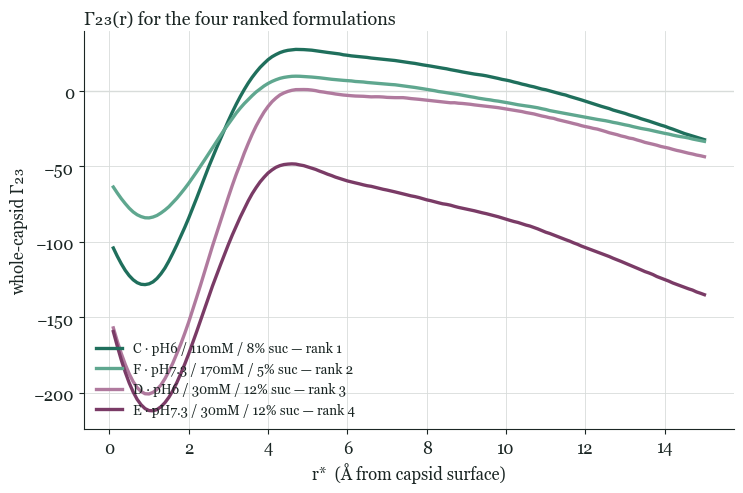

In [7]:
formulation_conds = sorted(
    (c for c in CONDITIONS if c["label"]),
    key=lambda c: STABILITY_ORDER.index(c["label"]),
)

fig, ax = plt.subplots(figsize=(7.6, 5.1))
colors = {"C": TEAL, "F": "#5fa78f", "D": "#b07a9e", "E": PLUM}
for c in formulation_conds:
    label = f"{c['label']} \u00b7 pH{c['ph']:g} / {c['salt']}mM / {c['suc']}% suc \u2014 rank {c['rank']}"
    ax.plot(c["r"], c["g"], color=colors[c["label"]], linewidth=2.4, label=label)
ax.axhline(0, color=GRID, linewidth=1, zorder=0)
ax.grid(True, color=GRID, linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
ax.set_xlabel("r*  (\u00c5 from capsid surface)")
ax.set_ylabel("whole-capsid \u0393\u2082\u2083")
ax.legend(fontsize=9.5, loc="lower left", frameon=False)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.set_title("\u0393\u2082\u2083(r) for the four ranked formulations", fontsize=13, loc="left")
fig.tight_layout()

## 2 · Formulation ranking, forest plot with corrected error bars

Same four formulations, endpoint value only, with `CORR`-inflated SEMs.
The ranking order is correct, but check which pairs actually clear 2×SE
before trusting the fine structure.

pairwise separations:
  C vs F: |diff|=   1.1  se=  29.1  ratio=0.04x  
  C vs D: |diff|=  11.3  se=  48.9  ratio=0.23x  
  C vs E: |diff|= 102.6  se=  34.5  ratio=2.97x  SIG
  F vs D: |diff|=  10.1  se=  46.1  ratio=0.22x  
  F vs E: |diff|= 101.4  se=  30.4  ratio=3.34x  SIG
  D vs E: |diff|=  91.3  se=  49.7  ratio=1.84x  


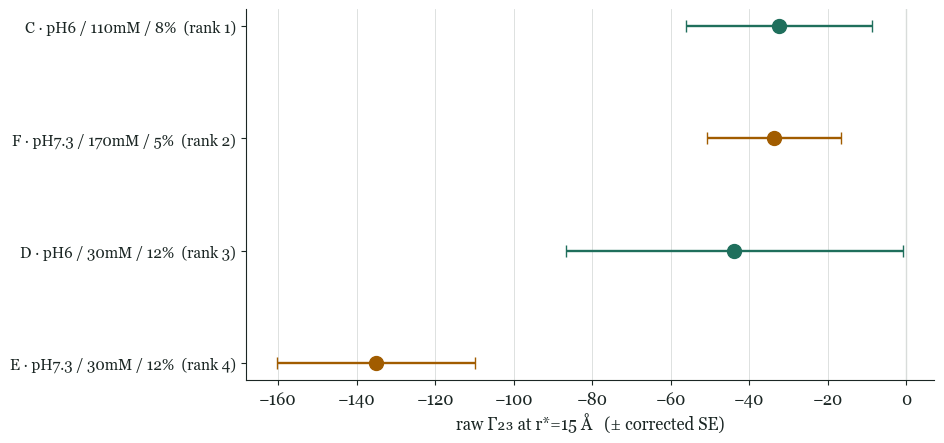

In [8]:
fig, ax = plt.subplots(figsize=(9.6, 4.6))
ypos = np.arange(len(formulation_conds))[::-1]
for i, c in enumerate(formulation_conds):
    color = TEAL if c["ph"] == 6.0 else AMBER
    ax.errorbar(c["g"][-1], ypos[i], xerr=c["sem"][-1] * CORR, fmt="o",
                color=color, ecolor=color, markersize=10, capsize=4, elinewidth=1.7)
ax.set_yticks(ypos)
ax.set_yticklabels([f"{c['label']} \u00b7 pH{c['ph']:g} / {c['salt']}mM / {c['suc']}%  (rank {c['rank']})"
                     for c in formulation_conds], fontsize=11)
ax.axvline(0, color=GRID, linewidth=1, zorder=0)
ax.grid(True, axis="x", color=GRID, linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
ax.set_xlabel("raw \u0393\u2082\u2083 at r*=15 \u00c5   (\u00b1 corrected SE)")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.tight_layout()

print("pairwise separations:")
for i in range(len(formulation_conds)):
    for j in range(i + 1, len(formulation_conds)):
        a, b = formulation_conds[i], formulation_conds[j]
        diff = abs(a["g"][-1] - b["g"][-1])
        se = np.hypot(a["sem"][-1] * CORR, b["sem"][-1] * CORR)
        print(f"  {a['label']} vs {b['label']}: |diff|={diff:6.1f}  se={se:6.1f}  ratio={diff/se:.2f}x"
              f"  {'SIG' if diff/se > 2 else ''}")

## 3 · DOE factorial effects: raw Γ₂₃ vs. normalized δ

All 8 DOE corners (2×2×2 in pH / salt / sucrose) solved as a saturated
factorial -- every effect below is exact, not a least-squares fit, since a
full 2³ design has exactly 8 degrees of freedom for 8 points.

Left panel (raw Γ₂₃) answers "how much does the formulation actually do."
Right panel (δ = Γ₂₃/mole_ratio, an effective per-molecule depletion
thickness in Å) answers "why" -- only pH survives there, because sucrose's
effect on raw Γ₂₃ is mostly just *more molecules*, not stronger exclusion
per molecule.

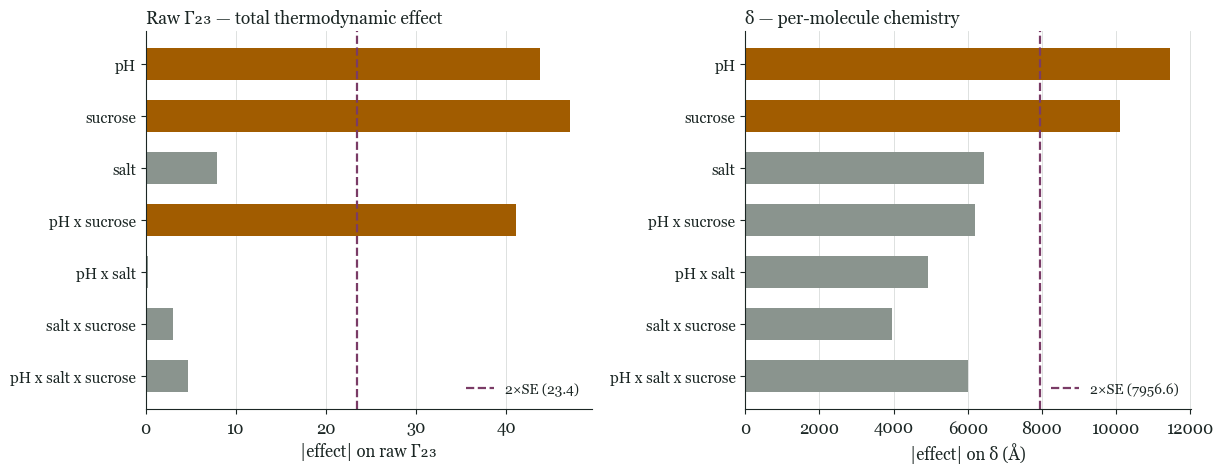

In [9]:
def factorial_effects(values, sems):
    """Exact effects for a saturated 2x2x2 factorial (pH, salt, sucrose),
    coded -1/+1 low/high. Returns (effects dict, propagated SE, X matrix).
    """
    X, y, s = [], [], []
    for salt, suc in DOE_CORNERS:
        for ph in (6.0, 8.0):
            cph = -1.0 if ph == 6.0 else 1.0
            csalt = -1.0 if salt == 30 else 1.0
            csuc = -1.0 if suc == 1 else 1.0
            X.append([1, cph, csalt, csuc, cph*csalt, cph*csuc, csalt*csuc, cph*csalt*csuc])
            key = (ph, salt, suc)
            y.append(values[key]); s.append(sems[key])
    X, y, s = np.array(X), np.array(y), np.array(s)
    coef = np.linalg.solve(X.T @ X, X.T @ y)
    effect = 2 * coef  # full effect = high-average minus low-average
    se = np.sqrt(np.sum((0.25**2) * s**2))  # same weight magnitude for every contrast column
    names = ["intercept", "pH", "salt", "sucrose", "pH x salt", "pH x sucrose",
             "salt x sucrose", "pH x salt x sucrose"]
    return dict(zip(names, effect)), se


raw_vals   = {k: BY_KEY[k]["g"][-1]            for k in BY_KEY if k not in {(6.0,110,8),(7.3,170,5),(6.0,30,12),(7.3,30,12)}}
raw_sems   = {k: BY_KEY[k]["sem"][-1] * CORR   for k in raw_vals}
delta_vals = {k: BY_KEY[k]["g"][-1] / BY_KEY[k]["mole_ratio"] for k in raw_vals}
delta_sems = {k: raw_sems[k] / BY_KEY[k]["mole_ratio"]         for k in raw_vals}

eff_raw, se_raw = factorial_effects(raw_vals, raw_sems)
eff_delta, se_delta = factorial_effects(delta_vals, delta_sems)

names = ["pH", "sucrose", "salt", "pH x sucrose", "pH x salt", "salt x sucrose", "pH x salt x sucrose"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.4, 4.9))
yp = np.arange(len(names))[::-1]
for ax, eff, se, xlabel, title in (
    (a1, eff_raw, se_raw, "|effect| on raw \u0393\u2082\u2083", "Raw \u0393\u2082\u2083 \u2014 total thermodynamic effect"),
    (a2, eff_delta, se_delta, "|effect| on \u03b4 (\u00c5)", "\u03b4 \u2014 per-molecule chemistry"),
):
    colors = [AMBER if abs(eff[n]) / se > 2 else GREY for n in names]
    ax.barh(yp, [abs(eff[n]) for n in names], color=colors, height=0.6)
    ax.axvline(2 * se, color=PLUM, ls="--", linewidth=1.6, label=f"2\u00d7SE ({2*se:.1f})")
    ax.set_yticks(yp); ax.set_yticklabels(names, fontsize=11)
    ax.set_xlabel(xlabel); ax.set_title(title, fontsize=12.5, loc="left")
    ax.grid(True, axis="x", color=GRID, linewidth=0.6, zorder=0); ax.set_axisbelow(True)
    ax.legend(frameon=False, fontsize=10, loc="lower right")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
fig.tight_layout()

## 4 · Why normalizing isn't a free lunch: the raw/δ decomposition

`raw Γ₂₃ ≈ K · δ · sucrose%` — verified below to hold to a few percent
across all 12 conditions. δ (chemistry, pH-driven) and sucrose% (loading)
multiply to give the raw value; a formulation's raw Γ₂₃ can be large either
because it's chemically more excluding, because it carries more sucrose, or
both. E is extreme because it's the only formulation far out on *both* axes.

K (median across 12 conditions) = 2.206   (spread 2.021 - 2.262)


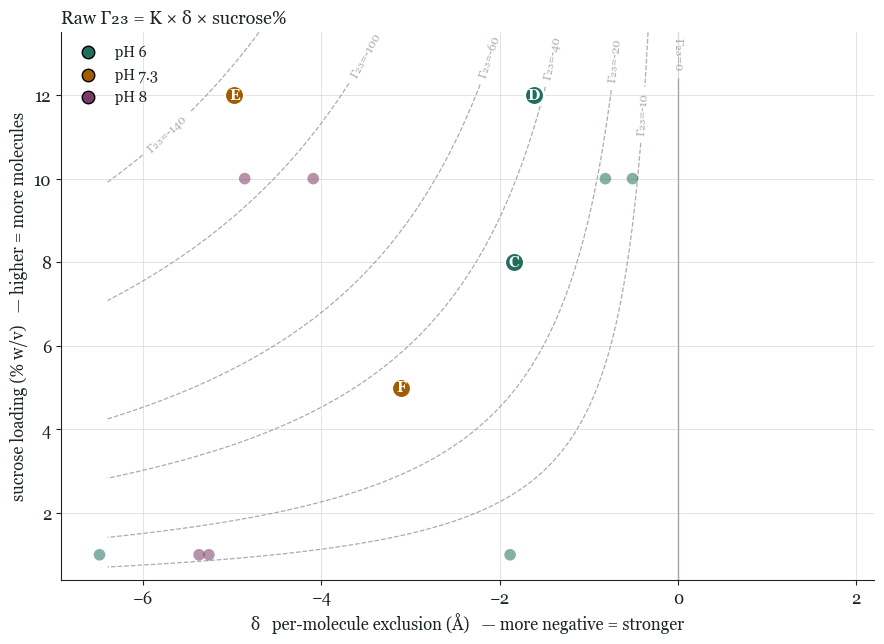

In [10]:
# delta here is an effective depletion-LAYER THICKNESS in Angstroms, not just
# g/mole_ratio: excess volume (G23-G21, from dividing by bulk water number
# density) divided by capsid surface area. That extra conversion is what
# makes delta ~O(1-5) A and K ~O(2), matching the original derivation --
# using g/mole_ratio alone here would make K degenerate to mole_ratio/suc%,
# independent of g (an easy mistake: check this cell's K against ~2.2 if
# you ever touch RHO_W or R_SURF below).
RHO_W = 0.0334          # bulk water number density, molecules/A^3
R_SURF = 105.0          # capsid exterior cutoff, ~effective surface radius, A
A_SURF = 4 * np.pi * R_SURF**2

def delta_of(c):
    excess_vol = (c["g"][-1] / c["mole_ratio"]) / RHO_W   # G23 - G21, A^3
    return excess_vol / A_SURF                             # A

Ks = [c["g"][-1] / (delta_of(c) * c["suc"]) for c in CONDITIONS if c["suc"] > 0]
K = float(np.median(Ks))
print(f"K (median across {len(Ks)} conditions) = {K:.3f}   (spread {min(Ks):.3f} - {max(Ks):.3f})")

fig, ax = plt.subplots(figsize=(9.0, 6.6))
dgrid = np.linspace(-6.4, 2.2, 400)
sgrid = np.linspace(0.4, 13.5, 400)
Dg, Sg = np.meshgrid(dgrid, sgrid)
cs = ax.contour(Dg, Sg, K * Dg * Sg, levels=[-140,-100,-60,-40,-20,-10,0], colors=GREY, linewidths=0.9, alpha=0.75)
ax.clabel(cs, fmt=lambda v: f"\u0393\u2082\u2083={v:.0f}", fontsize=8.5, inline=True)

for c in CONDITIONS:
    delta = delta_of(c)
    color = TEAL if c["ph"] == 6.0 else (AMBER if c["ph"] == 7.3 else PLUM)
    is_form = c["label"] is not None
    ax.scatter(delta, c["suc"], s=190 if is_form else 70, color=color,
               edgecolors="white" if is_form else "none", linewidths=1.6,
               alpha=1.0 if is_form else 0.55, zorder=4)
    if is_form:
        ax.annotate(c["label"], (delta, c["suc"]), color="white", fontsize=10.5,
                    fontweight="bold", ha="center", va="center", zorder=5)

ax.set_xlabel("\u03b4   per-molecule exclusion (\u00c5)   \u2014 more negative = stronger")
ax.set_ylabel("sucrose loading (% w/v)   \u2014 higher = more molecules")
ax.axvline(0, color=GRID, linewidth=1, zorder=0)
ax.grid(True, color=GRID, linewidth=0.55, zorder=0); ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(handles=[Line2D([0],[0],marker='o',color='none',markerfacecolor=c,markersize=9,label=n)
                   for c,n in [(TEAL,"pH 6"), (AMBER,"pH 7.3"), (PLUM,"pH 8")]],
          frameon=False, fontsize=10.5, loc="upper left")
ax.set_title("Raw \u0393\u2082\u2083 = K \u00d7 \u03b4 \u00d7 sucrose%", fontsize=13, loc="left")
fig.tight_layout()

## 5 · All 12 conditions, unified

Whole-capsid score (left) with the region-level detail retained (right,
individual 3-fold/5-fold means jittered, group means as bold dots). Rows
are sorted by score within each block; formulations on top, DOE corners
below. Set `NORMALIZE = True` to switch both panels to per-mole-ratio units
(they use the *same* normalizer, so each panel keeps measuring what it
started with -- see the note below the cell if you're editing this).

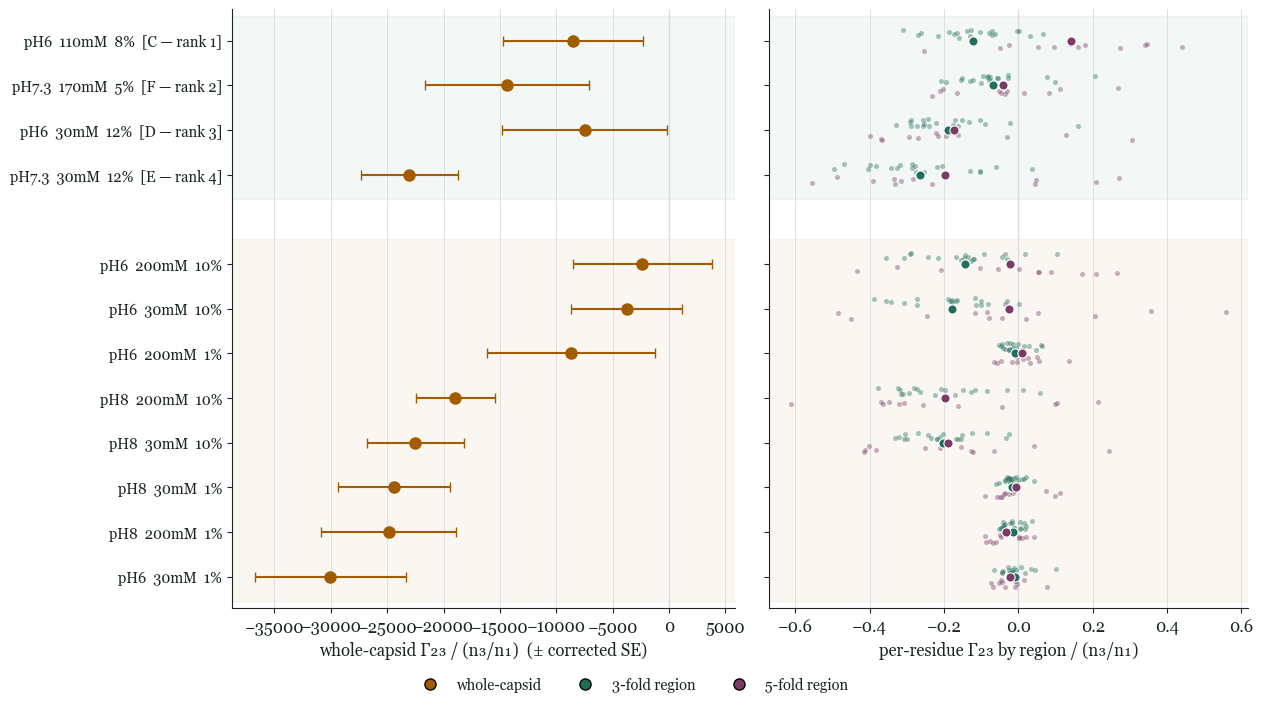

In [11]:
NORMALIZE = True  # flip to True for concentration-normalized units

forms = sorted((c for c in CONDITIONS if c["label"]), key=lambda c: c["rank"])
does = sorted((c for c in CONDITIONS if not c["label"]),
              key=lambda c: -(c["g"][-1] / c["mole_ratio"] if NORMALIZE else c["g"][-1]))
ordered = forms + [None] + does

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.8, 7.0), gridspec_kw={"width_ratios": [1.05, 1]})
rng = np.random.default_rng(7)
y, yticks, ylabels, pos = 0, [], [], {}
for c in ordered:
    if c is None:
        y -= 1; continue
    pos[id(c)] = y; yticks.append(y)
    tag = f"  [{c['label']} \u2014 rank {c['rank']}]" if c["label"] else ""
    ylabels.append(f"pH{c['ph']:g}  {c['salt']}mM  {c['suc']}%{tag}")
    y -= 1

f_ys = [pos[id(c)] for c in forms]; d_ys = [pos[id(c)] for c in does]
for ax in (axL, axR):
    ax.axhspan(max(f_ys)+0.55, min(f_ys)-0.55, color=TEAL, alpha=0.05, zorder=0)
    ax.axhspan(max(d_ys)+0.55, min(d_ys)-0.55, color=AMBER, alpha=0.05, zorder=0)

for c in forms + does:
    yy = pos[id(c)]
    denom = c["mole_ratio"] if NORMALIZE else 1.0
    axL.errorbar(c["g"][-1]/denom, yy, xerr=c["sem"][-1]*CORR/denom, fmt="o", color=AMBER,
                 ecolor=AMBER, markersize=8, capsize=3.5, elinewidth=1.5, zorder=3)
    for vals, color, sign in ((c["reg3"], TEAL, +1), (c["reg5"], PLUM, -1)):
        if vals.size == 0:
            continue
        j = rng.uniform(0.06, 0.24, size=len(vals))
        axR.scatter(vals, yy + sign*j, s=13, color=color, alpha=0.4, linewidths=0, zorder=2)
    if c["reg3"].size:
        axR.scatter([c["reg3"].mean()], [yy], s=44, color=TEAL, edgecolors="white", linewidths=0.8, zorder=4)
    if c["reg5"].size:
        axR.scatter([c["reg5"].mean()], [yy], s=44, color=PLUM, edgecolors="white", linewidths=0.8, zorder=4)

axL.set_xlabel(("whole-capsid \u0393\u2082\u2083 / (n\u2083/n\u2081)" if NORMALIZE else "whole-capsid \u0393\u2082\u2083") + "  (\u00b1 corrected SE)")
axR.set_xlabel("per-residue \u0393\u2082\u2083 by region" + (" / (n\u2083/n\u2081)" if NORMALIZE else ""))
for ax, tl in ((axL, ylabels), (axR, [])):
    ax.axvline(0, color=GRID, linewidth=1, zorder=0)
    ax.grid(True, axis="x", color=GRID, linewidth=0.6, zorder=0); ax.set_axisbelow(True)
    ax.set_yticks(yticks); ax.set_yticklabels(tl, fontsize=10.5)
    ax.set_ylim(min(yticks)-0.7, max(yticks)+0.7)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
fig.legend(handles=[
    Line2D([0],[0],marker='o',color='none',markerfacecolor=AMBER,markersize=8,label='whole-capsid'),
    Line2D([0],[0],marker='o',color='none',markerfacecolor=TEAL,markersize=8,label='3-fold region'),
    Line2D([0],[0],marker='o',color='none',markerfacecolor=PLUM,markersize=8,label='5-fold region'),
], loc="lower center", ncol=3, frameon=False, fontsize=10.5, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=[0, 0.02, 1, 1])

> **Normalizer note** (only matters if you're editing this cell): both panels
> above divide by the same `mole_ratio` and nothing else. An earlier version
> of this notebook additionally divided the region panel by bulk water
> density to get a volume in Å³ -- don't reintroduce that. It made the two
> panels measure genuinely different things (whole-capsid PIC vs. a
> per-residue excess *volume*) rather than the same quantity in normalized
> units, which silently broke the "both panels, same normalizer" invariant.

## 6 · pH 6 vs. pH 8 at one condition

Raw (left) and concentration-normalized (right) Γ₂₃(r) for a single
salt/sucrose corner. Change `SALT, SUC` and re-run. The two panels look
almost identical whenever pH 6 and pH 8 carry nearly the same bulk sucrose
loading (true for every DOE corner here, since salt/sucrose are matched by
construction within a pair) -- that near-equality is what makes any single
pH-pair comparison largely insensitive to the raw-vs-normalized choice,
unlike comparisons *across* sucrose%.

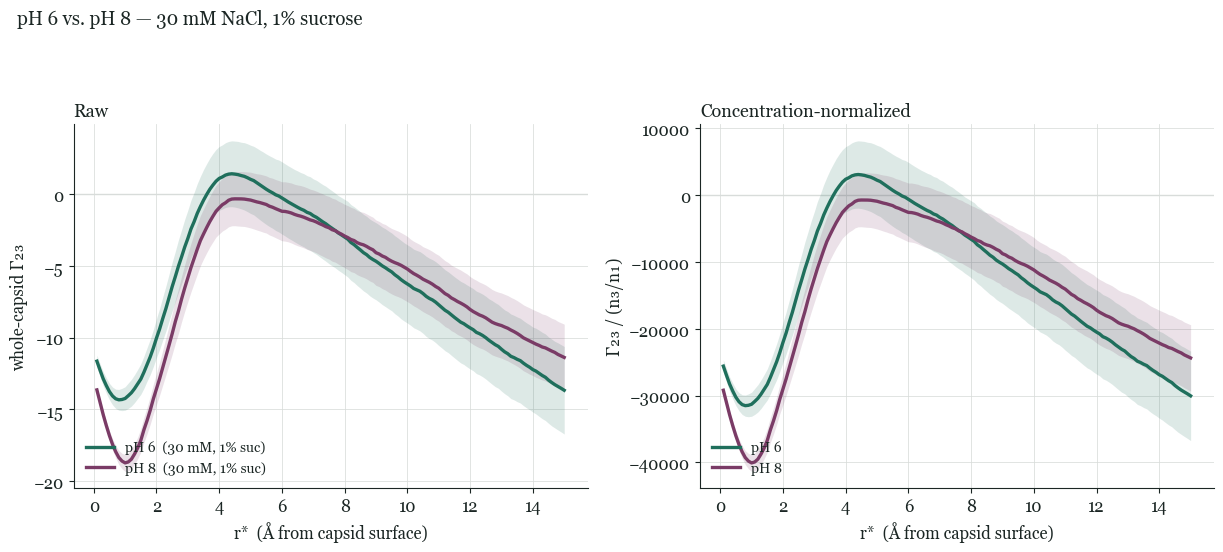

In [12]:
SALT, SUC = 30, 1  # edit and re-run

c6, c8 = BY_KEY[(6.0, SALT, SUC)], BY_KEY[(8.0, SALT, SUC)]
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.4, 5.4))
for cond, color, label in ((c6, TEAL, "pH 6"), (c8, PLUM, "pH 8")):
    axL.plot(cond["r"], cond["g"], color=color, linewidth=2.4, label=f"{label}  ({SALT} mM, {SUC}% suc)")
    axL.fill_between(cond["r"], cond["g"]-cond["sem"]*CORR, cond["g"]+cond["sem"]*CORR, color=color, alpha=0.15, linewidth=0)
    gn, sn = cond["g"]/cond["mole_ratio"], cond["sem"]*CORR/cond["mole_ratio"]
    axR.plot(cond["r"], gn, color=color, linewidth=2.4, label=label)
    axR.fill_between(cond["r"], gn-sn, gn+sn, color=color, alpha=0.15, linewidth=0)
axL.set_ylabel("whole-capsid \u0393\u2082\u2083"); axL.set_title("Raw", fontsize=13, loc="left")
axR.set_ylabel("\u0393\u2082\u2083 / (n\u2083/n\u2081)"); axR.set_title("Concentration-normalized", fontsize=13, loc="left")
for ax in (axL, axR):
    ax.axhline(0, color=GRID, linewidth=1, zorder=0)
    ax.grid(True, color=GRID, linewidth=0.55, zorder=0); ax.set_axisbelow(True)
    ax.set_xlabel("r*  (\u00c5 from capsid surface)")
    ax.legend(frameon=False, fontsize=10, loc="lower left")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
fig.suptitle(f"pH 6 vs. pH 8 \u2014 {SALT} mM NaCl, {SUC}% sucrose", fontsize=13.5, x=0.02, ha="left", y=1.02)
fig.tight_layout(rect=[0,0,1,0.95])

## 7 · pH 6 vs. pH 8 across the full DOE grid

One panel per salt x sucrose corner, shared y-axis on purpose: it keeps the
1% and 10% panels honestly comparable (the 1% panels are not "boring," they
are genuinely much smaller in raw magnitude -- see Section 9). Set
`SHARE_Y = False` for independent per-panel scaling if you want to see each
curve's own shape instead.

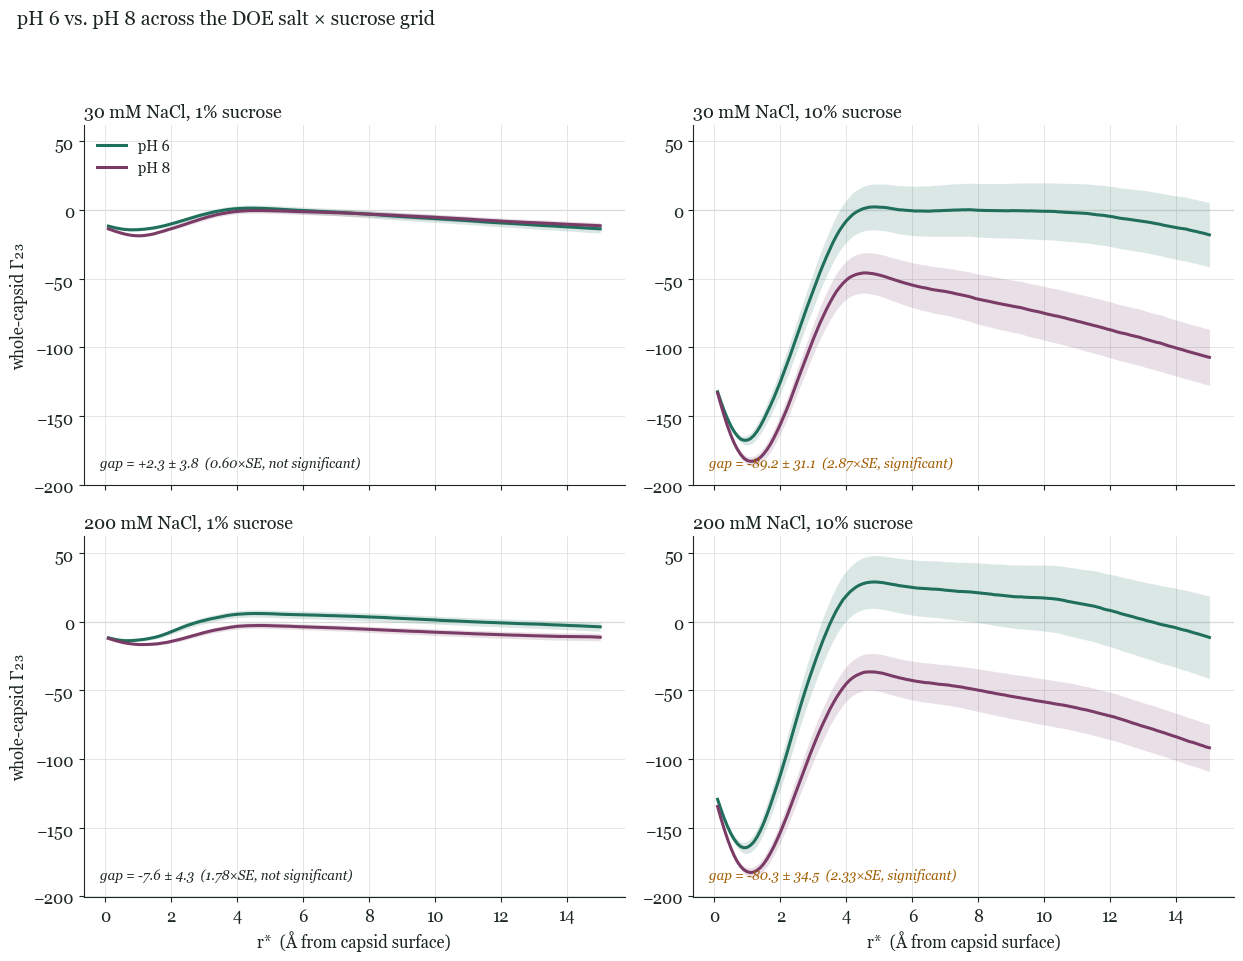

In [13]:
SHARE_Y = True

fig, axes = plt.subplots(2, 2, figsize=(12.6, 9.6), sharex=True)
grid = [[(30,1), (30,10)], [(200,1), (200,10)]]
all_y = []
for i in range(2):
    for j in range(2):
        salt, suc = grid[i][j]
        ax = axes[i][j]
        for ph, color in ((6.0, TEAL), (8.0, PLUM)):
            c = BY_KEY[(ph, salt, suc)]
            ax.plot(c["r"], c["g"], color=color, linewidth=2.2, label=f"pH {ph:g}")
            band = c["sem"] * CORR
            ax.fill_between(c["r"], c["g"]-band, c["g"]+band, color=color, alpha=0.16, linewidth=0)
            all_y.extend([(c["g"]-band).min(), (c["g"]+band).max()])
        gs = gap_stats(salt, suc)
        sig = "significant" if gs["ratio"] > 2 else "not significant"
        ax.annotate(f"gap = {gs['gap']:+.1f} \u00b1 {gs['se']:.1f}  ({gs['ratio']:.2f}\u00d7SE, {sig})",
                    xy=(0.03, 0.05), xycoords="axes fraction", fontsize=9.5,
                    color=AMBER if gs["ratio"] > 2 else INK, style="italic")
        ax.axhline(0, color=GRID, linewidth=1, zorder=0)
        ax.grid(True, color=GRID, linewidth=0.5, zorder=0); ax.set_axisbelow(True)
        ax.set_title(f"{salt} mM NaCl, {suc}% sucrose", fontsize=13, loc="left")
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)
        if i == 1: ax.set_xlabel("r*  (\u00c5 from capsid surface)")
        if j == 0: ax.set_ylabel("whole-capsid \u0393\u2082\u2083")

if SHARE_Y:
    lo, hi = min(all_y), max(all_y)
    pad = 0.06 * (hi - lo)
    for row in axes:
        for ax in row:
            ax.set_ylim(lo - pad, hi + pad)

axes[0][0].legend(frameon=False, fontsize=10.5, loc="upper left")
fig.suptitle("pH 6 vs. pH 8 across the DOE salt \u00d7 sucrose grid", fontsize=14, x=0.02, ha="left", y=1.0)
fig.tight_layout(rect=[0,0,1,0.96])

## 8 · pH-gap forest plot at a chosen radius

One point per pH per condition at a single r (not the curve endpoint) --
useful for checking whether a conclusion is r*-dependent. Set `R_TARGET`
and `NORMALIZE`.

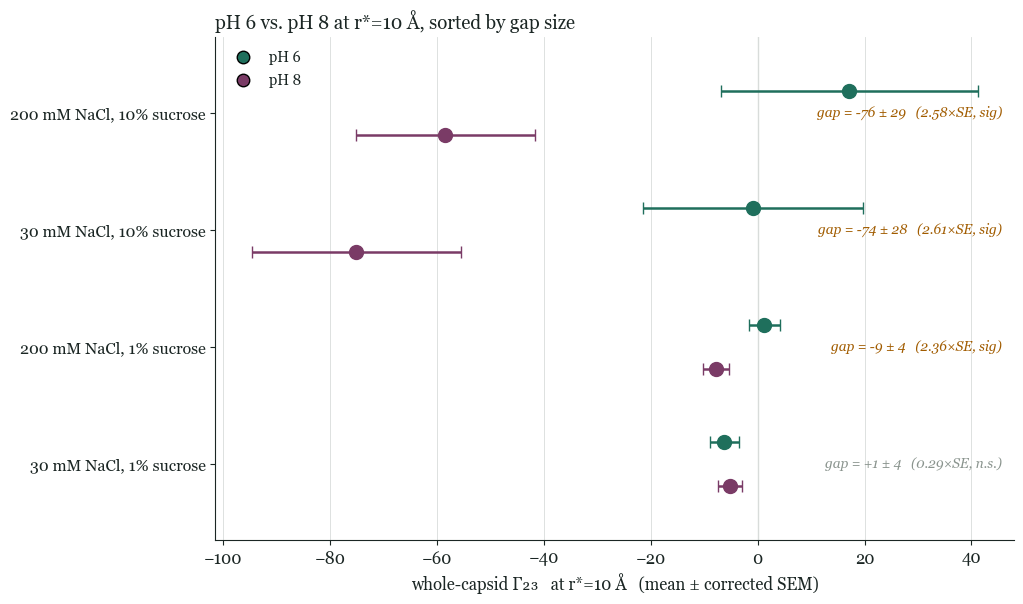

In [14]:
R_TARGET = 10.0
NORMALIZE = False

order = sorted(DOE_CORNERS, key=lambda k: -abs(gap_stats(*k, r_target=R_TARGET, normalize=NORMALIZE)["gap"]))

fig, ax = plt.subplots(figsize=(10.4, 6.2))
y, yticks, ylabels = 0, [], []
for salt, suc in order:
    gs = gap_stats(salt, suc, r_target=R_TARGET, normalize=NORMALIZE)
    ax.errorbar(gs["g6"], y+0.19, xerr=gs["s6"], fmt="o", color=TEAL, ecolor=TEAL, markersize=10, capsize=4, elinewidth=1.8, zorder=3)
    ax.errorbar(gs["g8"], y-0.19, xerr=gs["s8"], fmt="o", color=PLUM, ecolor=PLUM, markersize=10, capsize=4, elinewidth=1.8, zorder=3)
    sig = gs["ratio"] > 2
    ax.text(0.985, y, f"gap = {gs['gap']:+.0f} \u00b1 {gs['se']:.0f}   ({gs['ratio']:.2f}\u00d7SE{', sig' if sig else ', n.s.'})",
            transform=ax.get_yaxis_transform(), fontsize=9.8, color=AMBER if sig else GREY, va="center", ha="right", style="italic")
    yticks.append(y); ylabels.append(f"{salt} mM NaCl, {suc}% sucrose"); y -= 1.0

ax.set_yticks(yticks); ax.set_yticklabels(ylabels, fontsize=11.5)
ax.axvline(0, color=GRID, linewidth=1, zorder=0)
ax.grid(True, axis="x", color=GRID, linewidth=0.6, zorder=0); ax.set_axisbelow(True)
unit = "\u0393\u2082\u2083 / (n\u2083/n\u2081)" if NORMALIZE else "\u0393\u2082\u2083"
ax.set_xlabel(f"whole-capsid {unit}   at r*={R_TARGET:g} \u00c5   (mean \u00b1 corrected SEM)")
ax.set_ylim(min(yticks)-0.65, max(yticks)+0.65)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(handles=[Line2D([0],[0],marker='o',color='none',markerfacecolor=TEAL,markersize=9,label='pH 6'),
                   Line2D([0],[0],marker='o',color='none',markerfacecolor=PLUM,markersize=9,label='pH 8')],
          frameon=False, fontsize=10.5, loc="lower left" if NORMALIZE else "best")
ax.set_title(f"pH 6 vs. pH 8 at r*={R_TARGET:g} \u00c5, sorted by gap size", fontsize=13.5, loc="left")
fig.tight_layout()

## 9 · Comparing gap *sizes* across conditions

For "which condition has the biggest pH-gap," use raw units (left) --
comparing normalized gaps across *different* sucrose% mixes two things
(mole-ratio rescaling and genuine chemistry) and can invert the ranking
(right; see markdown discussion in the chat history / report for the full
mechanism -- briefly, raw gap grows sub-linearly with concentration while
mole_ratio grows linearly, so dividing by mole_ratio over-corrects and
inflates the low-concentration gap).

does SUCROSE change the pH-gap itself? (fixed salt, gap(10%) - gap(1%))
  30 mM: Delta(gap) =  -75.28 +/- 28.68  (2.62x SE)
  200 mM: Delta(gap) =  -66.69 +/- 29.53  (2.26x SE)
does SALT change the pH-gap itself? (fixed sucrose, gap(200mM) - gap(30mM))
  1% suc: Delta(gap) =   -9.96 +/-  5.19  (1.92x SE)
  10% suc: Delta(gap) =   -1.37 +/- 40.84  (0.03x SE)


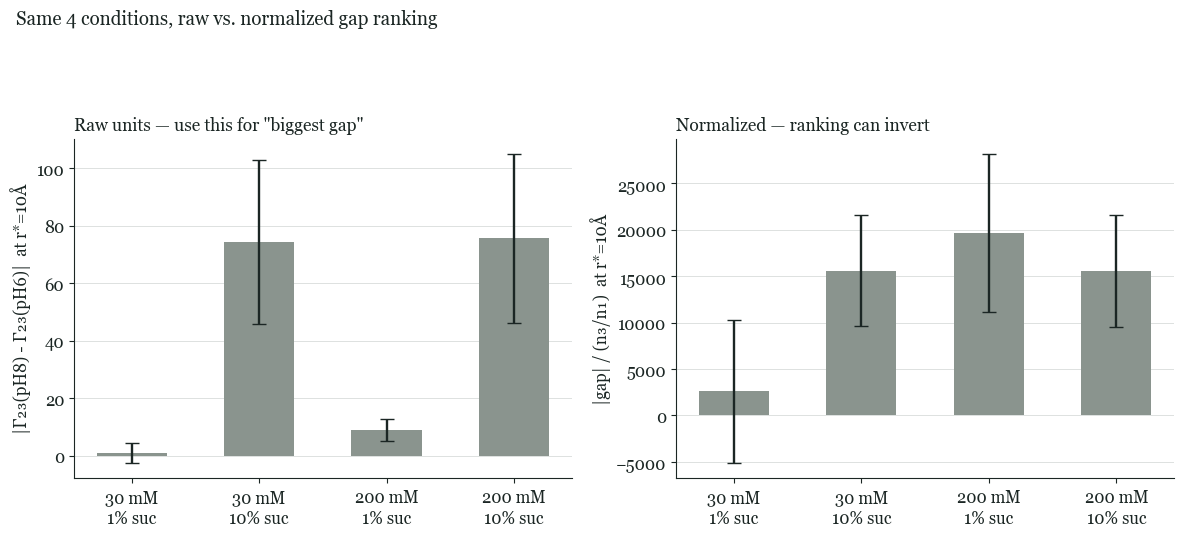

In [15]:
R_TARGET = 10.0

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.0, 5.2))
labels = [f"{s} mM\n{c}% suc" for s, c in DOE_CORNERS]

raw_gaps = [gap_stats(s, c, r_target=R_TARGET) for s, c in DOE_CORNERS]
a1.bar(labels, [abs(g["gap"]) for g in raw_gaps], yerr=[g["se"] for g in raw_gaps],
       color=GREY, width=0.55, error_kw=dict(elinewidth=1.7, capsize=5, ecolor=INK))
a1.set_ylabel(f"|\u0393\u2082\u2083(pH8) - \u0393\u2082\u2083(pH6)|  at r*={R_TARGET:g}\u00c5")
a1.set_title("Raw units \u2014 use this for \"biggest gap\"", fontsize=12.5, loc="left")

norm_gaps = [gap_stats(s, c, r_target=R_TARGET, normalize=True) for s, c in DOE_CORNERS]
a2.bar(labels, [abs(g["gap"]) for g in norm_gaps], yerr=[g["se"] for g in norm_gaps],
       color=GREY, width=0.55, error_kw=dict(elinewidth=1.7, capsize=5, ecolor=INK))
a2.set_ylabel(f"|gap| / (n\u2083/n\u2081)  at r*={R_TARGET:g}\u00c5")
a2.set_title("Normalized \u2014 ranking can invert", fontsize=12.5, loc="left")

for ax in (a1, a2):
    ax.grid(True, axis="y", color=GRID, linewidth=0.6, zorder=0); ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
fig.suptitle("Same 4 conditions, raw vs. normalized gap ranking", fontsize=13.5, x=0.02, ha="left", y=1.03)
fig.tight_layout(rect=[0,0,1,0.93])

print("does SUCROSE change the pH-gap itself? (fixed salt, gap(10%) - gap(1%))")
for salt in (30, 200):
    a, b = gap_stats(salt, 10, r_target=R_TARGET), gap_stats(salt, 1, r_target=R_TARGET)
    d, se = a["gap"] - b["gap"], np.hypot(a["se"], b["se"])
    print(f"  {salt} mM: Delta(gap) = {d:7.2f} +/- {se:5.2f}  ({abs(d)/se:.2f}x SE)")

print("does SALT change the pH-gap itself? (fixed sucrose, gap(200mM) - gap(30mM))")
for suc in (1, 10):
    a, b = gap_stats(200, suc, r_target=R_TARGET), gap_stats(30, suc, r_target=R_TARGET)
    d, se = a["gap"] - b["gap"], np.hypot(a["se"], b["se"])
    print(f"  {suc}% suc: Delta(gap) = {d:7.2f} +/- {se:5.2f}  ({abs(d)/se:.2f}x SE)")

## 10 · Is the 3-fold/5-fold region spread real structure, or shot noise?

Region-level Γ₂₃ is also an excess count, so its *spread* across the 32
regions should also scale with concentration -- the question is *how fast*.
Real structural differences between regions would scale linearly with
concentration (spread ∝ N); pure counting noise scales as the square root
(spread ∝ √N, Poisson). Fitting the exponent settles which one this is.

fitted exponent p in  std(region) ~ concentration^p  :  p = 0.61
  p = 1.0 would mean real structural variation; p = 0.5 means Poisson counting noise

5F - 3F gap per condition (SE from between-region scatter, NOT frame-corrected --
this test's error already comes from real region-to-region variation, correcting
it again for frame correlation would double-count):
  pH6      30mM  1%   gap= -0.0116  se= 0.0145   0.80x  
  pH6      30mM 10%   gap= +0.1529  se= 0.0908   1.68x  
  pH6      30mM 12%   gap= +0.0153  se= 0.0665   0.23x  
  pH6     110mM  8%   gap= +0.2631  se= 0.0609   4.32x  SIG
  pH6     200mM  1%   gap= +0.0182  se= 0.0181   1.01x  
  pH6     200mM 10%   gap= +0.1213  se= 0.0669   1.81x  
  pH7.3    30mM 12%   gap= +0.0682  se= 0.0844   0.81x  
  pH7.3   170mM  5%   gap= +0.0253  se= 0.0483   0.52x  
  pH8      30mM  1%   gap= +0.0097  se= 0.0196   0.49x  
  pH8      30mM 10%   gap= +0.0154  se= 0.0621   0.25x  
  pH8     200mM  1%   gap= -0.0181  se= 0.0145   1.25x  
  pH

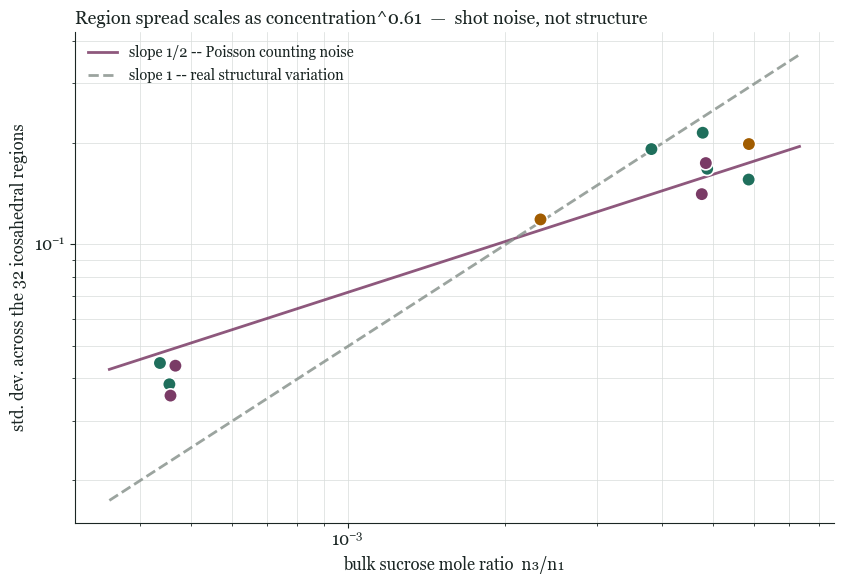

In [16]:
mole_ratios = np.array([c["mole_ratio"] for c in CONDITIONS])
spreads = np.array([np.concatenate([c["reg3"], c["reg5"]]).std(ddof=1) for c in CONDITIONS])

p_fit, _ = np.polyfit(np.log(mole_ratios), np.log(spreads), 1)
print(f"fitted exponent p in  std(region) ~ concentration^p  :  p = {p_fit:.2f}")
print("  p = 1.0 would mean real structural variation; p = 0.5 means Poisson counting noise")

fig, ax = plt.subplots(figsize=(8.6, 6.0))
xs = np.logspace(np.log10(mole_ratios.min()*0.8), np.log10(mole_ratios.max()*1.25), 100)
xa, ya = np.exp(np.mean(np.log(mole_ratios))), np.exp(np.mean(np.log(spreads)))
for slope, color, label, ls in ((0.5, PLUM, "slope 1/2 -- Poisson counting noise", "-"),
                                 (1.0, GREY, "slope 1 -- real structural variation", "--")):
    ax.plot(xs, ya*(xs/xa)**slope, ls, color=color, linewidth=2.0, alpha=0.85, label=label, zorder=2)
colors = [TEAL if c["ph"]==6.0 else (AMBER if c["ph"]==7.3 else PLUM) for c in CONDITIONS]
ax.scatter(mole_ratios, spreads, s=95, c=colors, zorder=4, edgecolors="white", linewidths=1.2)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("bulk sucrose mole ratio  n\u2083/n\u2081")
ax.set_ylabel("std. dev. across the 32 icosahedral regions")
ax.grid(True, which="both", color=GRID, linewidth=0.5, zorder=0); ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(frameon=False, fontsize=10.5, loc="upper left")
ax.set_title(f"Region spread scales as concentration^{p_fit:.2f}  \u2014  shot noise, not structure",
             fontsize=13, loc="left")
fig.tight_layout()

print()
print("5F - 3F gap per condition (SE from between-region scatter, NOT frame-corrected --")
print("this test's error already comes from real region-to-region variation, correcting")
print("it again for frame correlation would double-count):")
n_sig = 0
for c in sorted(CONDITIONS, key=lambda c: (c["ph"], c["salt"], c["suc"])):
    if c["reg3"].size == 0 or c["reg5"].size == 0:
        continue
    gap = c["reg5"].mean() - c["reg3"].mean()
    se = np.sqrt(c["reg3"].var(ddof=1)/len(c["reg3"]) + c["reg5"].var(ddof=1)/len(c["reg5"]))
    ratio = abs(gap)/se if se > 0 else 0
    n_sig += ratio > 2
    print(f"  pH{c['ph']:<4g} {c['salt']:>4d}mM {c['suc']:>2d}%   gap={gap:+8.4f}  se={se:7.4f}  {ratio:5.2f}x  {'SIG' if ratio>2 else ''}")
print(f"\n{n_sig}/{len(CONDITIONS)} significant at 2xSE (~{0.05*len(CONDITIONS):.1f} expected by chance)")

## 11 · Replicate check: pH 6 / 30 mM / 1% sucrose, THREE independent trials

`10ns_aav1ph6salt30suc1` has now been simulated three separate times.
Naming, for the record (folder names alone don't make the history obvious):

| folder | what it is | timestamp |
|---|---|---|
| `10ns_aav1ph6salt30suc1-rerun1` | the **original** run (this was briefly renamed aside as `old-...-old` while only 2 trials existed; despite the "-rerun1" name it is the first trial chronologically) | 2026-07-13 |
| `10ns_aav1ph6salt30suc1` (no suffix) | second trial | 2026-07-16 |
| `10ns_aav1ph6salt30suc1_rerun2` | third trial | 2026-07-20 |

None of the two suffixed folders match `FOLDER_RE` (Section 0 requires the
name to end right after `suc#`), so both are correctly excluded from
`CONDITIONS`/`BY_KEY` -- confirmed by the "skipped" printout in Section 0.
`load_raw_curve` reads a folder by exact name, bypassing that strict
matching, specifically so checks like this one can never touch `BY_KEY`.

**Also note:** trial 3 was run with `--radius 30` instead of `--radius 15`
(300 r-bins vs. 150) -- its `r_values` array simply goes further, so
`curve["g"][-1]` means r*=30 Å for trial 3 but r*=15 Å for the other two.
Comparisons below explicitly look up r*=15 Å on all three rather than
trusting `[-1]`, and trial 3's extra range (15-30 Å) gets its own check.

In [17]:
def load_raw_curve(folder_name):
    """Load one condition's curve + metadata by exact folder name,
    bypassing FOLDER_RE -- for one-off checks that must never touch BY_KEY.
    """
    path = ROOT / folder_name
    with open(path / "pic_SUC_exterior_vs_r.csv") as fh:
        rows = list(csv.DictReader(fh))
    r = np.array([float(x["r_angstrom"]) for x in rows])
    g = np.array([float(x["gamma23_mean"]) for x in rows])
    sem = np.array([float(x["gamma23_sem"]) for x in rows])
    with open(path / "pic_SUC_exterior.pkl", "rb") as fh:
        meta = pickle.load(fh)["metadata"]
    return dict(r=r, g=g, sem=sem, meta=meta)


def value_at_raw(run, r_target):
    i = int(np.argmin(np.abs(run["r"] - r_target)))
    assert abs(run["r"][i] - r_target) < 1e-6, f"no exact r={r_target} in this run"
    return run["g"][i], run["sem"][i]


TRIALS = {
    "trial 1 (original)": load_raw_curve("10ns_aav1ph6salt30suc1-rerun1"),
    "trial 2":            load_raw_curve("10ns_aav1ph6salt30suc1"),
    "trial 3":            load_raw_curve("10ns_aav1ph6salt30suc1_rerun2"),
}
TRIAL_COLORS = {"trial 1 (original)": GREY, "trial 2": TEAL, "trial 3": AMBER}

print("=== metadata: genuine independent replicates? ===")
for k in ("gro", "n_frames", "timestamp",
          "mean_exterior_water_per_frame", "mean_exterior_excipient_per_frame"):
    vals = "   ".join(f"{label}={run['meta'].get(k)!r}" for label, run in TRIALS.items())
    print(f"  {k}:\n    {vals}")

=== metadata: genuine independent replicates? ===
  gro:
    trial 1 (original)='aav1/10ns_aav1ph6salt30suc1/md.gro'   trial 2='aav1/10ns_aav1ph6salt30suc1_rerun/md.gro'   trial 3='aav1/10ns_aav1ph6salt30suc1_rerun2/md.gro'
  n_frames:
    trial 1 (original)=990   trial 2=1001   trial 3=1001
  timestamp:
    trial 1 (original)='2026-07-13 11:37:17'   trial 2='2026-07-16 09:48:52'   trial 3='2026-07-20 10:22:14'
  mean_exterior_water_per_frame:
    trial 1 (original)=735913.1472392638   trial 2=735913.4775224775   trial 3=736049.6273726274
  mean_exterior_excipient_per_frame:
    trial 1 (original)=338.0   trial 2=335.0   trial 3=337.0


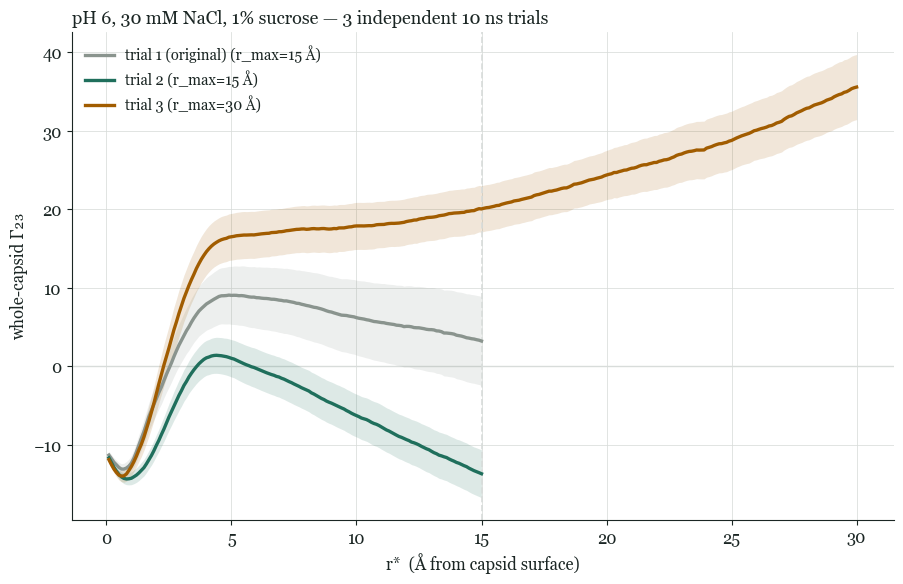

In [18]:
fig, ax = plt.subplots(figsize=(9.2, 6.0))
for label, run in TRIALS.items():
    color = TRIAL_COLORS[label]
    band = run["sem"] * CORR
    ax.plot(run["r"], run["g"], color=color, linewidth=2.4,
            label=f"{label} (r_max={run['r'][-1]:g} \u00c5)")
    ax.fill_between(run["r"], run["g"]-band, run["g"]+band, color=color, alpha=0.15, linewidth=0)
ax.axvline(15, color=GRID, linewidth=1.2, ls="--", zorder=1)
ax.axhline(0, color=GRID, linewidth=1, zorder=0)
ax.grid(True, color=GRID, linewidth=0.55, zorder=0); ax.set_axisbelow(True)
ax.set_xlabel("r*  (\u00c5 from capsid surface)")
ax.set_ylabel("whole-capsid \u0393\u2082\u2083")
ax.legend(frameon=False, fontsize=10.5, loc="upper left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.set_title("pH 6, 30 mM NaCl, 1% sucrose \u2014 3 independent 10 ns trials", fontsize=13, loc="left")
fig.tight_layout()

### How much do they actually disagree?

All three at r*=15 Å (the radius all three share), plus every pairwise gap
against its own combined, frame-correlation-corrected SE.

In [19]:
labels = list(TRIALS.keys())
vals_sems = {l: value_at_raw(TRIALS[l], 15.0) for l in labels}

print("Gamma23 at r*=15 A:")
for l in labels:
    g, s = vals_sems[l]
    print(f"  {l:20s}  {g:7.2f} +/- {s*CORR:5.2f}")

print("\npairwise (corrected SE):")
worst_ratio = 0.0
for i in range(3):
    for j in range(i+1, 3):
        a, b = labels[i], labels[j]
        ga, sa = vals_sems[a]; gb, sb = vals_sems[b]
        diff = ga - gb
        se = np.hypot(sa*CORR, sb*CORR)
        ratio = abs(diff)/se
        worst_ratio = max(worst_ratio, ratio)
        print(f"  {a} vs {b}: diff={diff:7.2f}  se={se:5.2f}  ratio={ratio:.2f}x")

import math
p_two_tailed = math.erfc(worst_ratio / math.sqrt(2))
print(f"\nP(|Z| > {worst_ratio:.2f}) under a correctly-calibrated Gaussian = {p_two_tailed:.2e}")
print("-- i.e. CORR=8.5 alone does not explain a disagreement this large.")

g_vals = np.array([vals_sems[l][0] for l in labels])
mean_se = np.mean([vals_sems[l][1]*CORR for l in labels])
print(f"\nacross the 3 trials: mean={g_vals.mean():.2f}  std={g_vals.std(ddof=1):.2f}"
      f"   (vs. typical single-trial corrected SE ~{mean_se:.2f})")
print(f"empirical between-trial spread is ~{g_vals.std(ddof=1)/mean_se:.1f}x the corrected single-run SE")

Gamma23 at r*=15 A:
  trial 1 (original)       3.22 +/-  5.66
  trial 2                -13.67 +/-  3.05
  trial 3                 20.04 +/-  2.96

pairwise (corrected SE):
  trial 1 (original) vs trial 2: diff=  16.89  se= 6.43  ratio=2.63x
  trial 1 (original) vs trial 3: diff= -16.82  se= 6.39  ratio=2.63x
  trial 2 vs trial 3: diff= -33.71  se= 4.25  ratio=7.93x

P(|Z| > 7.93) under a correctly-calibrated Gaussian = 2.13e-15
-- i.e. CORR=8.5 alone does not explain a disagreement this large.

across the 3 trials: mean=3.19  std=16.86   (vs. typical single-trial corrected SE ~3.89)
empirical between-trial spread is ~4.3x the corrected single-run SE


### Trial 3's own extended range: does it ever flatten?

Trial 3 ran out to r*=30 Å. If Γ₂₃(r) had reached a real plateau by 15 Å,
extending the same run further shouldn't move the value much.

In [20]:
r3, g3, sem3 = TRIALS["trial 3"]["r"], TRIALS["trial 3"]["g"], TRIALS["trial 3"]["sem"]
for r_target in (15, 18, 20, 22, 25, 28, 30):
    i = int(np.argmin(np.abs(r3 - r_target)))
    print(f"  r={r3[i]:5.1f}  Gamma23={g3[i]:7.2f} +/- {sem3[i]*CORR:5.2f}")
print(f"\nrise from r=15 to r=30: {g3[-1]-value_at_raw(TRIALS['trial 3'],15.0)[0]:+.1f}"
      f"  -- still climbing, not flat")

  r= 15.0  Gamma23=  20.04 +/-  2.96
  r= 18.0  Gamma23=  22.44 +/-  3.00
  r= 20.0  Gamma23=  24.35 +/-  3.13
  r= 22.0  Gamma23=  25.95 +/-  3.44
  r= 25.0  Gamma23=  28.75 +/-  3.72
  r= 28.0  Gamma23=  32.84 +/-  4.07
  r= 30.0  Gamma23=  35.55 +/-  4.15

rise from r=15 to r=30: +15.5  -- still climbing, not flat


### What this means for conclusions drawn earlier

Section 9 tested whether the pH 6-vs-pH 8 gap changes with sucrose/salt
using a single trial per corner, including this one. With three trials
landing at +3.2, -13.7, and +20.0 at the same nominal condition, **this
corner's true value is not known to within anything like the precision
that analysis assumed** -- and there's no principled way to pick one of the
three trials as "the" answer over the others. Treat any conclusion that
leans on the 30 mM/1% corner specifically (rather than the DOE pattern as a
whole) as unresolved rather than as a small-but-significant effect, until
there are enough replicates here to average over, or a longer/enhanced-
sampling approach replaces brute-force trials for this specific corner.

## 12 · AAV8 / AAV2 salt study (Na⁺ / Cl⁻, no sucrose)

A separate batch: `pic_suc_7_9/salt/`, sibling to this notebook's own
directory. AAV8 at pH 6 and pH 8, AAV2 at pH 7.3, each at 30 mM and 300 mM
NaCl with **no sucrose** -- 3 (serotype/pH) x 2 (ion) x 2 (salt) = 12
conditions, one run each, no replicates yet.

Loaded separately from `CONDITIONS`/`BY_KEY` above (different folder-naming
convention, different excipients, different capsid serotypes -- keeping it
in its own namespace avoids any risk of the two studies' keys colliding).

In [21]:
# ROOT.parent alone is a no-op here: Path(".").parent lexically returns "."
# again rather than "..", since pathlib doesn't resolve dots against the
# filesystem unless asked to.
SALT_ROOT = ROOT.resolve().parent / "salt"
SALT_FOLDER_RE = re.compile(r"^pic_(na|cl)_(aav\d)_ph(\d+)_salt(\d+)_30A$")

def load_salt_condition(path):
    m = SALT_FOLDER_RE.match(path.name)
    if not m:
        return None
    ion, serotype, ph_raw, salt = m.groups()
    ion = ion.upper()
    ph = 7.3 if ph_raw == "73" else float(ph_raw)
    salt = int(salt)

    with open(path / f"pic_{ion}_exterior_vs_r.csv") as fh:
        rows = list(csv.DictReader(fh))
    r = np.array([float(x["r_angstrom"]) for x in rows])
    g = np.array([float(x["gamma23_mean"]) for x in rows])
    sem = np.array([float(x["gamma23_sem"]) for x in rows])

    with open(path / f"pic_{ion}_exterior.pkl", "rb") as fh:
        meta = pickle.load(fh)["metadata"]

    # tail slope over the last 2 A -- the convergence check this dataset
    # needs, since r*=30 A is its ONLY radius (no 15 A cross-check like the
    # sucrose study had).
    i28 = int(np.argmin(np.abs(r - 28)))
    slope_tail = (g[-1] - g[i28]) / (r[-1] - r[i28])

    return dict(name=path.name, ion=ion, serotype=serotype, ph=ph, salt=salt,
                r=r, g=g, sem=sem, meta=meta, slope_tail=slope_tail)


SALT_CONDITIONS = [c for c in (load_salt_condition(p) for p in sorted(SALT_ROOT.iterdir()) if p.is_dir()) if c]
print(f"loaded {len(SALT_CONDITIONS)} salt-study conditions from {SALT_ROOT}")

print(f"\n{'condition':38s} {'Gamma(r*=30A)':>13s} {'tail slope':>11s}  converged?")
for c in sorted(SALT_CONDITIONS, key=lambda c: (c['ion'], c['serotype'], c['ph'], c['salt'])):
    flat = abs(c["slope_tail"]) < 0.3
    print(f"{c['name']:38s} {c['g'][-1]:13.2f} {c['slope_tail']:11.2f}  {'flat' if flat else 'STILL MOVING'}")

loaded 12 salt-study conditions from C:\Users\shrim\Downloads\pic_results\pic_suc_7_9\salt

condition                              Gamma(r*=30A)  tail slope  converged?
pic_cl_aav2_ph73_salt30_30A                    60.22        0.38  STILL MOVING
pic_cl_aav2_ph73_salt300_30A                 -214.16       -0.97  STILL MOVING
pic_cl_aav8_ph6_salt30_30A                     96.86        0.21  flat
pic_cl_aav8_ph6_salt300_30A                  -178.93       -5.37  STILL MOVING
pic_cl_aav8_ph8_salt30_30A                    -61.61       -0.64  STILL MOVING
pic_cl_aav8_ph8_salt300_30A                  -355.58       -3.05  STILL MOVING
pic_na_aav2_ph73_salt30_30A                   -64.42       -2.00  STILL MOVING
pic_na_aav2_ph73_salt300_30A                 -371.03       -2.61  STILL MOVING
pic_na_aav8_ph6_salt30_30A                    -82.30       -1.34  STILL MOVING
pic_na_aav8_ph6_salt300_30A                  -396.69       -5.19  STILL MOVING
pic_na_aav8_ph8_salt30_30A                     23

### All 12 curves, Na⁺ and Cl⁻ side by side

Dashed = 30 mM, solid = 300 mM. Every 300 mM curve is still trending at
r*=30 Å -- there is no 15 Å cross-check available for this dataset the way
there was for sucrose, so this is the only convergence evidence there is
right now.

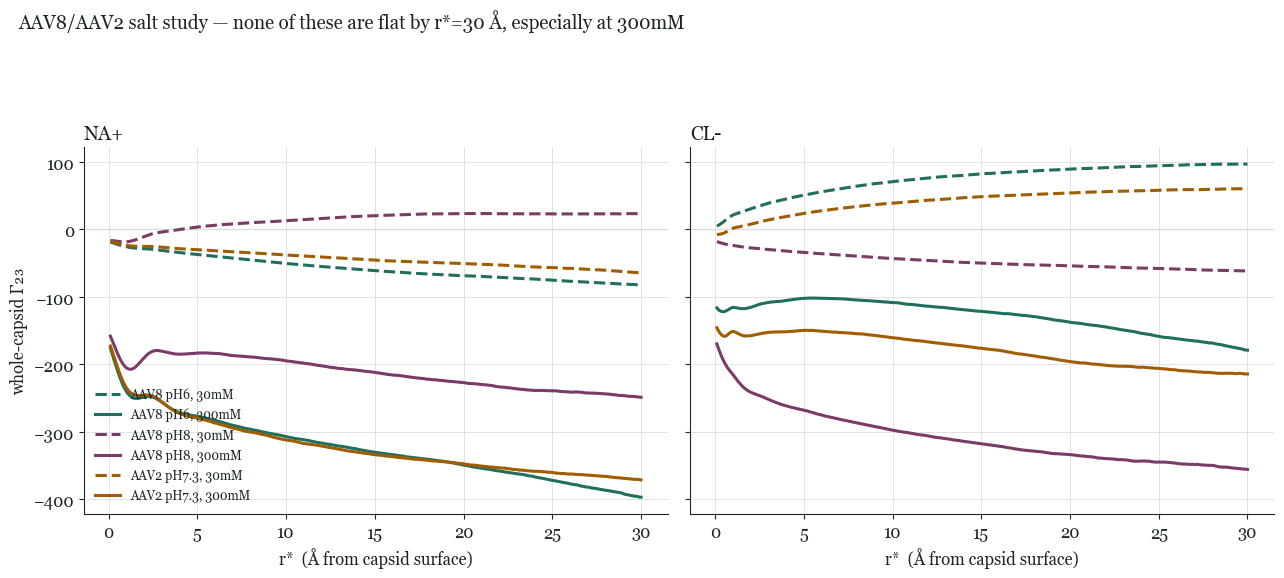

In [22]:
SALT_SERIES = [("aav8", 6.0, TEAL, "AAV8 pH6"), ("aav8", 8.0, PLUM, "AAV8 pH8"),
               ("aav2", 7.3, AMBER, "AAV2 pH7.3")]
SALT_BY_KEY = {(c["ion"], c["serotype"], c["ph"], c["salt"]): c for c in SALT_CONDITIONS}

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.6), sharey=True)
for ax, ion in zip(axes, ["NA", "CL"]):
    for serotype, ph, color, label in SALT_SERIES:
        for salt, ls in ((30, "--"), (300, "-")):
            c = SALT_BY_KEY[(ion, serotype, ph, salt)]
            ax.plot(c["r"], c["g"], ls, color=color, linewidth=2.2,
                    label=f"{label}, {salt}mM" if ion == "NA" else None)
    ax.axhline(0, color=GRID, linewidth=1, zorder=0)
    ax.grid(True, color=GRID, linewidth=0.55, zorder=0); ax.set_axisbelow(True)
    ax.set_xlabel("r*  (\u00c5 from capsid surface)")
    ax.set_title(f"{ion}{'+' if ion=='NA' else '-'}", fontsize=14, loc="left")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("whole-capsid \u0393\u2082\u2083")
axes[0].legend(frameon=False, fontsize=9, loc="lower left")
fig.suptitle("AAV8/AAV2 salt study \u2014 none of these are flat by r*=30 \u00c5, especially at 300mM",
             fontsize=13.5, x=0.02, ha="left", y=1.03)
fig.tight_layout(rect=[0, 0, 1, 0.93])

### Endpoint summary, sorted by |Γ₂₃|, convergence flagged

Same "point + corrected error bar" forest-plot convention as the rest of
this notebook. Marker shape distinguishes converged from still-moving
conditions -- **treat the still-moving ones as provisional lower bounds on
the magnitude**, not final numbers, since every one of them is still
trending more negative.

The frame-correlation correction here uses ion-specific bulk diffusion
coefficients (Na⁺ 0.133 Å²/ps, Cl⁻ 0.203 Å²/ps -- faster than sucrose's
0.052 Å²/ps) over this dataset's wider 30 Å shell, which is a real but
different tradeoff than the sucrose study's 15 Å shell: ions cross faster,
but there's more distance to cross.

NA: tau~1128 ps -> ~8.9 independent samples -> CORR=10.63
CL: tau~739 ps -> ~13.5 independent samples -> CORR=8.60


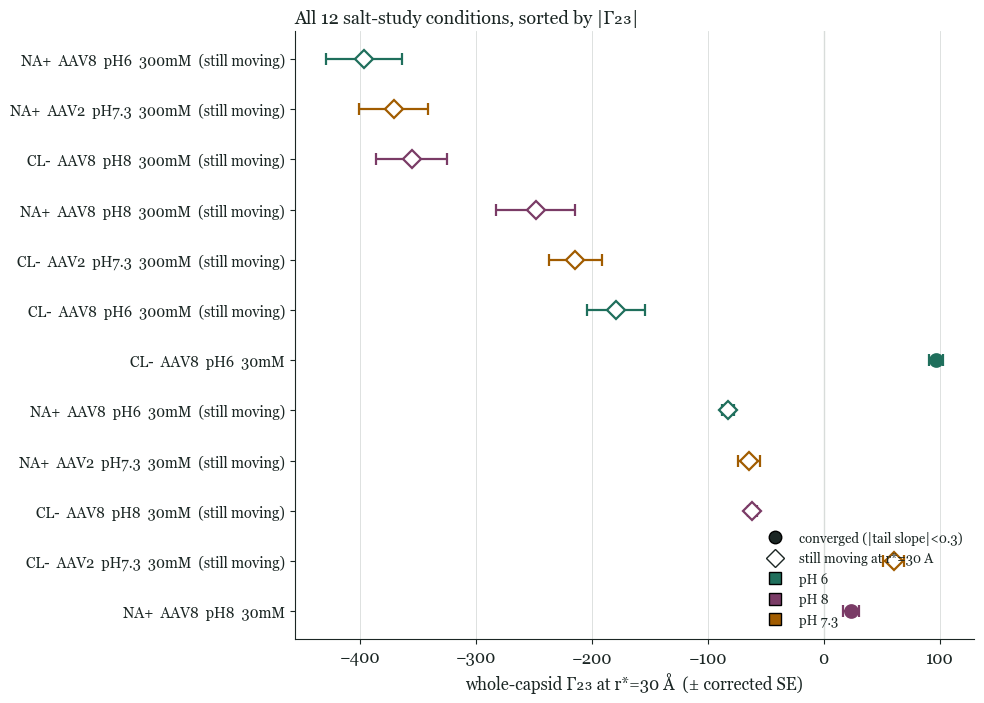

In [23]:
D_ION = {"NA": 0.133, "CL": 0.203}  # A^2/ps, bulk aqueous diffusion coefficients
L_SALT = 30.0  # A, this dataset's local-domain width

CORR_ION = {}
for ion, D in D_ION.items():
    tau = L_SALT**2 / (6 * D)
    n_eff = 10000.0 / tau  # 10 ns run
    CORR_ION[ion] = np.sqrt(1001.0 / n_eff)
    print(f"{ion}: tau~{tau:.0f} ps -> ~{n_eff:.1f} independent samples -> CORR={CORR_ION[ion]:.2f}")

ordered = sorted(SALT_CONDITIONS, key=lambda c: -abs(c["g"][-1]))
fig, ax = plt.subplots(figsize=(10.0, 7.2))
yticks, ylabels = [], []
for i, c in enumerate(ordered):
    y = -i
    corr = CORR_ION[c["ion"]]
    color = TEAL if c["ph"] == 6.0 else (PLUM if c["ph"] == 8.0 else AMBER)
    converged = abs(c["slope_tail"]) < 0.3
    marker = "o" if converged else "D"
    ax.errorbar(c["g"][-1], y, xerr=c["sem"][-1]*corr, fmt=marker, color=color,
                ecolor=color, markersize=9, capsize=4, elinewidth=1.6,
                markerfacecolor=color if converged else "white", markeredgewidth=1.6, zorder=3)
    yticks.append(y)
    ylabels.append(f"{c['ion']}{'+' if c['ion']=='NA' else '-'}  {c['serotype'].upper()}  "
                    f"pH{c['ph']:g}  {c['salt']}mM" + ("" if converged else "  (still moving)"))

ax.set_yticks(yticks); ax.set_yticklabels(ylabels, fontsize=10.5)
ax.axvline(0, color=GRID, linewidth=1, zorder=0)
ax.grid(True, axis="x", color=GRID, linewidth=0.6, zorder=0); ax.set_axisbelow(True)
ax.set_xlabel("whole-capsid \u0393\u2082\u2083 at r*=30 \u00c5  (\u00b1 corrected SE)")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(handles=[
    Line2D([0],[0],marker='o',color='none',markerfacecolor=INK,markersize=9,label='converged (|tail slope|<0.3)'),
    Line2D([0],[0],marker='D',color='none',markerfacecolor='white',markeredgecolor=INK,markersize=9,label='still moving at r*=30 A'),
    Line2D([0],[0],marker='s',color='none',markerfacecolor=TEAL,markersize=9,label='pH 6'),
    Line2D([0],[0],marker='s',color='none',markerfacecolor=PLUM,markersize=9,label='pH 8'),
    Line2D([0],[0],marker='s',color='none',markerfacecolor=AMBER,markersize=9,label='pH 7.3'),
], frameon=False, fontsize=9.5, loc="lower right")
ax.set_title("All 12 salt-study conditions, sorted by |\u0393\u2082\u2083|", fontsize=13, loc="left")
fig.tight_layout()

### Where this leaves things

Three of six ion/serotype pairs flip sign between 30 mM and 300 mM (Na⁺/AAV8
pH8, Cl⁻/AAV8 pH6, Cl⁻/AAV2 pH7.3) -- a much larger effect than anything in
the sucrose study, and plausibly consistent with Debye screening (a
compressed counter-ion atmosphere at high salt changing what a long-range
integration window picks up) -- but that is a hypothesis, not a finding.
Every 300 mM condition is still trending at r*=30 Å, so treat magnitudes as
provisional. Concrete next steps before drawing conclusions:
1. Extend `--radius` well past 30 Å (40-50 Å) for at least the 300 mM
   conditions and confirm an actual plateau.
2. Get a second independent trial for the conditions with the largest
   apparent effects, the same way Section 11 did for the sucrose study --
   a single run's reliability at this salt/sucrose-adjacent noise floor has
   already been shown to be worse than the frame-correlation correction
   alone predicts.